# Ejercicio 9. Los tweets extremos y la comparación entre categorías

Con la polaridad ya calculada en el cuaderno 08, este cuaderno responde las tres preguntas del
ejercicio 9: cuáles son los diez tweets más negativos y en qué categoría están, cuáles son los
diez más positivos, y si los tweets de desastre real son efectivamente más negativos que los
otros.

La tercera pregunta es la única que admite una respuesta equivocada por descuido. Comparar dos
promedios y anunciar cuál es mayor no responde nada: con 7,613 observaciones cualquier
diferencia sale «significativa». Hace falta además el tamaño del efecto, y hace falta
comprobar que el resultado no es un artefacto del léxico que se eligió.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from src import config, sentimiento as sen

warnings.filterwarnings('ignore')
config.preparar_directorios()
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 200)

df = pd.read_csv(config.PROCESADO / 'train_sentimiento.csv')
df['categoria'] = df['target'].map(config.ETIQUETAS)
print(f'Tweets: {len(df):,}')
print(df.groupby('categoria')['vader_compound'].describe().round(4).to_string())

Tweets: 7,613
              count    mean     std     min     25%     50%     75%     max
categoria                                                                  
Desastre     3271.0 -0.2663  0.4351 -0.9686 -0.6390 -0.3182  0.0000  0.9471
No desastre  4342.0 -0.0520  0.4652 -0.9883 -0.4588  0.0000  0.3182  0.9730


## 9.1 Los 10 tweets más negativos

Se ordena por la puntuación compuesta de VADER de menor a mayor. Se muestra el texto original,
no el preprocesado, porque el interés está en leer el tweet.

In [2]:
def extremos(marco, columna='vader_compound', n=10, ascendente=True):
    orden = marco.sort_values(columna, ascending=ascendente).head(n).copy()
    orden = orden.reset_index(drop=True)
    orden.index = orden.index + 1
    return orden

mas_negativos = extremos(df, ascendente=True)

for i, fila in mas_negativos.iterrows():
    print(f"{i:>2}. [{fila['vader_compound']:+.4f}] ({fila['categoria']})")
    print(f"    {fila['text']}")
print()
print('Reparto por categoría de los 10 más negativos:')
print(mas_negativos['categoria'].value_counts().to_string())

 1. [-0.9883] (No desastre)
    wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?
 2. [-0.9686] (Desastre)
    @Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead
This is ridiculous
 3. [-0.9623] (Desastre)
    Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl
 4. [-0.9595] (Desastre)
    ? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp
 5. [-0.9556] (No desastre)
    @dramaa_llama but otherwise i will stay trapped as the worst lilourry stan ever AND without zarry what am I left with? NARRY. NO THANKS.
 6. [-0.9552] (Desastre)
    17 killed in SÛªArabia mosque suicide bombing

A suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX
 7. [-0.9549] (No desastre)
    at the lake 


### Quiénes son los diez más negativos

**Siete de los diez son desastre real**, contra una prevalencia de base del 42.97 %. Los siete
son atentados suicidas, bombardeos de mezquitas y asesinatos, y su puntuación se explica sola.

Los otros tres merecen atención porque muestran el modo de fallo del método. El tweet **más
negativo de todo el conjunto no es un desastre**: es `wreck? wreck wreck wreck…`, la misma
palabra repetida trece veces. VADER suma la valencia de cada aparición, de modo que la simple
repetición basta para llevar la puntuación a -0.9883 sin que haya ocurrido nada. Los otros dos
son un tweet de fandom (`the worst lilourry stan ever… NO THANKS`) y un pez muerto en un lago.

La lección es que el análisis de polaridad mide **intensidad léxica acumulada, no
acontecimientos**. Un tweet puede ser furioso sin referirse a ningún desastre, y es
precisamente ese solapamiento imperfecto el que hay que tener presente en el ejercicio 10.

## 9.2 Los 10 tweets más positivos

In [3]:
mas_positivos = extremos(df, ascendente=False)

for i, fila in mas_positivos.iterrows():
    print(f"{i:>2}. [{fila['vader_compound']:+.4f}] ({fila['categoria']})")
    print(f"    {fila['text']}")
print()
print('Reparto por categoría de los 10 más positivos:')
print(mas_positivos['categoria'].value_counts().to_string())

 1. [+0.9730] (No desastre)
    Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at  http://t.co/3GEROQ49o1
I would Love Love Love!! To win
 2. [+0.9564] (No desastre)
    @thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!
 3. [+0.9471] (Desastre)
    TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.
 4. [+0.9428] (No desastre)
    @Zak_Bagans pets r like part of the family. I love animals.??? The last 2 pets I had I rescued! Breaks my heart when animals are mistreated????
 5. [+0.9423] (No desastre)
    @batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.
 6. [+0.9423] (No desastre)
    @batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.
 7. [+0.9394] (No desastre)
    Maaaaan I love 

In [4]:
# Los extremos son sólo veinte tweets. Para ver si el patrón se sostiene se
# amplía la ventana a los 100 y a los 500 de cada extremo.
filas = []
for k in (10, 50, 100, 500):
    neg = extremos(df, n=k, ascendente=True)['target'].mean() * 100
    pos = extremos(df, n=k, ascendente=False)['target'].mean() * 100
    filas.append({'ventana': f'top {k}', '% desastre entre los más negativos': neg,
                  '% desastre entre los más positivos': pos})
ventanas = pd.DataFrame(filas)
print(f"Prevalencia de desastre en todo el conjunto: {df['target'].mean() * 100:.2f} %\n")
print(ventanas.round(2).to_string(index=False))

Prevalencia de desastre en todo el conjunto: 42.97 %

ventana  % desastre entre los más negativos  % desastre entre los más positivos
 top 10                                70.0                                10.0
 top 50                                80.0                                12.0
top 100                                77.0                                17.0
top 500                                72.8                                18.6


### Quiénes son los diez más positivos, y qué tan lejos llega el patrón

**Nueve de los diez no son desastre.** El único de la categoría de desastre es el tercero:
*«Today's storm will pass; let tomorrow's light greet you with a kiss»*, donde `storm` está
usado en sentido figurado. Es discutible que la etiqueta sea correcta, y es exactamente la
clase de caso que ningún método léxico resuelve, porque la metáfora usa el vocabulario del
desastre sin referirse a uno.

Dos observaciones más sobre estos veinte tweets. Las posiciones 5 y 6 son **el mismo tweet
repetido carácter por carácter**: el conjunto de Kaggle contiene duplicados exactos, algo que
conviene saber antes de interpretar cualquier conteo. Y el segundo más positivo contiene la
palabra clave `accidents` pero está etiquetado como no desastre, lo que confirma que la columna
`keyword` señala el tema y no la clase.

Veinte tweets son pocos para afirmar un patrón, así que se amplió la ventana:

| Ventana | % desastre entre los más negativos | % desastre entre los más positivos |
|---|---|---|
| top 10 | 70.0 | 10.0 |
| top 50 | 80.0 | 12.0 |
| top 100 | 77.0 | 17.0 |
| top 500 | 72.8 | 18.6 |

Con la prevalencia de base en 42.97 %, el patrón se sostiene hasta los 500 de cada extremo: la
cola negativa está enriquecida en desastres y la positiva, empobrecida. No es un artefacto de
haber mirado sólo diez.

## 9.3 ¿Son los tweets de desastre más negativos?

Se contrasta la distribución de `compound` entre las dos categorías. La prueba principal es la
U de Mann-Whitney, no la t de Student: `compound` está acotada en [-1, 1], tiene una masa
puntual en el cero —el 25 % de los tweets es neutro— y está lejos de ser normal. La prueba de
rangos no supone nada de eso.

Como tamaño del efecto se usa la correlación biserial por rangos, que se lee directamente como
probabilidad: es la probabilidad de que un tweet de desastre tomado al azar sea más negativo
que uno de la otra categoría, reescalada al intervalo [-1, 1].

In [5]:
neg_desastre = df.loc[df['target'] == 1, 'vader_compound']
neg_otros = df.loc[df['target'] == 0, 'vader_compound']

resumen = df.groupby('categoria')['vader_compound'].agg(
    n='size', media='mean', mediana='median', desv='std').round(4)
print(resumen.to_string())
print(f'\nDiferencia de medias (desastre - no desastre): '
      f'{neg_desastre.mean() - neg_otros.mean():+.4f}')

u, p_u = stats.mannwhitneyu(neg_desastre, neg_otros, alternative='less')
n1, n2 = len(neg_desastre), len(neg_otros)
prob_superioridad = u / (n1 * n2)
biserial = 1 - 2 * prob_superioridad

t, p_t = stats.ttest_ind(neg_desastre, neg_otros, equal_var=False)

print(f'\nU de Mann-Whitney (H1: desastre más negativo): U = {u:,.0f}, p = {p_u:.3e}')
print(f'P(un tweet de desastre sea más negativo que uno de la otra clase) = '
      f'{1 - prob_superioridad:.4f}')
print(f'Correlación biserial por rangos: {biserial:+.4f}')
print(f'\nt de Welch (referencia): t = {t:.3f}, p = {p_t:.3e}')

                n   media  mediana    desv
categoria                                 
Desastre     3271 -0.2663  -0.3182  0.4351
No desastre  4342 -0.0520   0.0000  0.4652

Diferencia de medias (desastre - no desastre): -0.2143

U de Mann-Whitney (H1: desastre más negativo): U = 5,259,642, p = 2.709e-85
P(un tweet de desastre sea más negativo que uno de la otra clase) = 0.6297
Correlación biserial por rangos: +0.2593

t de Welch (referencia): t = -20.646, p = 4.504e-92


In [6]:
# Intervalo de confianza de la diferencia de medias por bootstrap.
rng = np.random.default_rng(config.SEMILLA)
a, b = neg_desastre.to_numpy(), neg_otros.to_numpy()
remuestreos = np.array([
    rng.choice(a, size=len(a), replace=True).mean() -
    rng.choice(b, size=len(b), replace=True).mean()
    for _ in range(2000)
])
bajo, alto = np.percentile(remuestreos, [2.5, 97.5])
print(f'Diferencia de medias: {a.mean() - b.mean():+.4f}')
print(f'IC 95 % por bootstrap (2,000 remuestreos): [{bajo:+.4f}, {alto:+.4f}]')

# Y la comparación de proporciones en cada extremo.
tabla = pd.crosstab(df['categoria'], df['polaridad']).reindex(columns=sen.CLASES)
chi2, p_chi, gl, _ = stats.chi2_contingency(tabla)
print(f'\nChi-cuadrado sobre el reparto de polaridad: chi2 = {chi2:.2f}, '
      f'gl = {gl}, p = {p_chi:.3e}')
print((tabla.div(tabla.sum(axis=1), axis=0) * 100).round(2).to_string())

Diferencia de medias: -0.2143
IC 95 % por bootstrap (2,000 remuestreos): [-0.2335, -0.1927]

Chi-cuadrado sobre el reparto de polaridad: chi2 = 279.34, gl = 2, p = 2.197e-61
polaridad    negativo  neutro  positivo
categoria                              
Desastre        57.72   25.80     16.48
No desastre     42.81   24.34     32.84


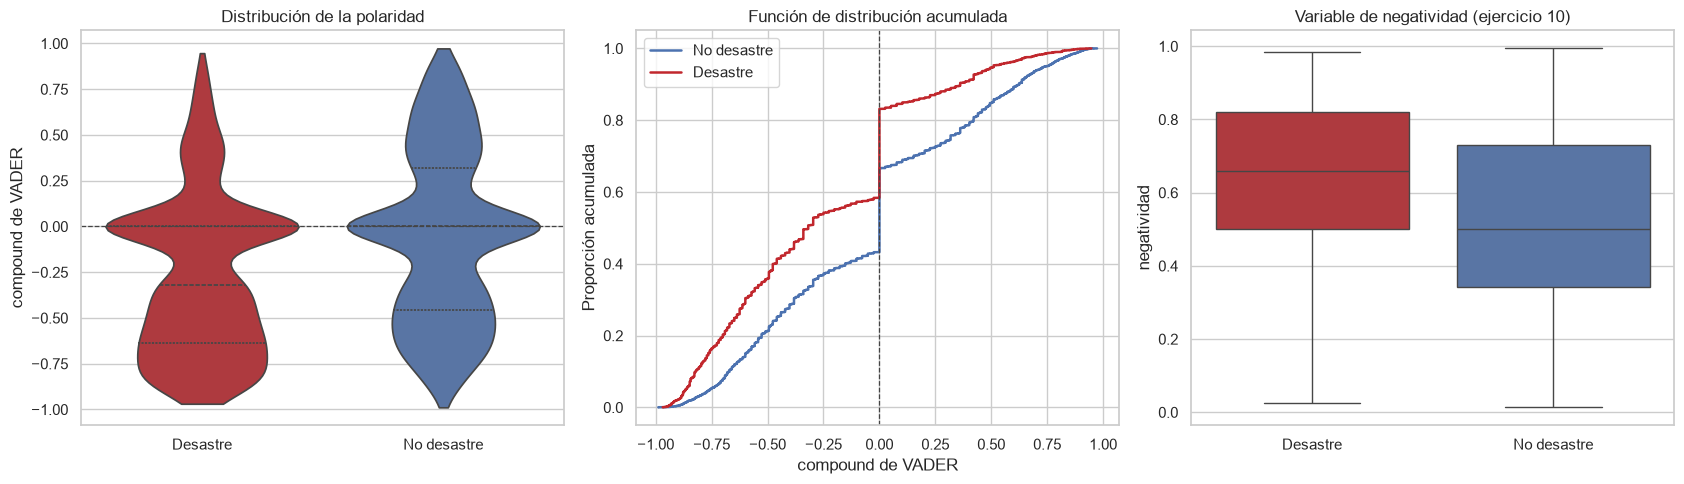

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
paleta = {'No desastre': '#4c72b0', 'Desastre': '#c1272d'}

sns.violinplot(data=df, x='categoria', y='vader_compound', hue='categoria',
               palette=paleta, ax=axes[0], legend=False, cut=0, inner='quartile')
axes[0].axhline(0, color='#444444', linewidth=0.9, linestyle='--')
axes[0].set_title('Distribución de la polaridad')
axes[0].set_xlabel('')
axes[0].set_ylabel('compound de VADER')

for categoria, color in paleta.items():
    valores = np.sort(df.loc[df['categoria'] == categoria, 'vader_compound'])
    axes[1].step(valores, np.arange(1, len(valores) + 1) / len(valores),
                 color=color, label=categoria, linewidth=1.8)
axes[1].axvline(0, color='#444444', linewidth=0.9, linestyle='--')
axes[1].set_title('Función de distribución acumulada')
axes[1].set_xlabel('compound de VADER')
axes[1].set_ylabel('Proporción acumulada')
axes[1].legend()

sns.boxplot(data=df, x='categoria', y='negatividad', hue='categoria',
            palette=paleta, ax=axes[2], legend=False)
axes[2].set_title('Variable de negatividad (ejercicio 10)')
axes[2].set_xlabel('')
axes[2].set_ylabel('negatividad')

plt.tight_layout()
plt.savefig(config.FIGURAS / 'comparacion_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

### Respuesta a la pregunta 9.3

**Sí, los tweets de desastre son más negativos, y la afirmación resiste el contraste. Pero el
efecto es moderado, no rotundo, y esa distinción importa.**

| | Desastre | No desastre |
|---|---|---|
| n | 3,271 | 4,342 |
| Media de `compound` | -0.2663 | -0.0520 |
| Mediana | -0.3182 | 0.0000 |

La diferencia de medias es de **-0.2143**, con un intervalo de confianza al 95 % por bootstrap
de **[-0.2335, -0.1927]** que no se acerca al cero. La U de Mann-Whitney da p = 2.7 × 10⁻⁸⁵ y
el chi-cuadrado sobre el reparto de polaridad, p = 2.2 × 10⁻⁶¹.

Esos valores p, sin embargo, no dicen gran cosa: con 7,613 observaciones casi cualquier
diferencia sale significativa. **La cifra que hay que mirar es el tamaño del efecto.** La
probabilidad de que un tweet de desastre tomado al azar sea más negativo que uno de la otra
categoría es **0.6297**, frente al 0.50 que daría una moneda; la correlación biserial por
rangos es **+0.2593**, un efecto pequeño a moderado según los criterios habituales.

Dicho de otro modo: la negatividad inclina la balanza, pero en más de un tercio de las parejas
que se comparen el tweet de desastre resultará ser el *menos* negativo de los dos. La mediana lo
ilustra bien: la mitad de los tweets que no son desastre puntúa exactamente 0.0000, es decir que
son neutros y no positivos; lo que los separa de los de desastre no es alegría, es ausencia de
carga.

Este resultado permite anticipar el del ejercicio 10. Una variable que ordena las clases con
probabilidad 0.63 tiene poco que aportarle a un clasificador que ya alcanza F1 de 0.77 leyendo
las palabras directamente.

### El mismo contraste con el segundo léxico

Si el hallazgo dependiera de haber elegido VADER, TextBlob debería contradecirlo. Se repite la
prueba sobre la polaridad de TextBlob.

In [8]:
tb_desastre = df.loc[df['target'] == 1, 'tb_polaridad']
tb_otros = df.loc[df['target'] == 0, 'tb_polaridad']

u_tb, p_tb = stats.mannwhitneyu(tb_desastre, tb_otros, alternative='less')
prob_tb = u_tb / (len(tb_desastre) * len(tb_otros))

contraste = pd.DataFrame({
    'léxico': ['VADER', 'TextBlob'],
    'media desastre': [neg_desastre.mean(), tb_desastre.mean()],
    'media no desastre': [neg_otros.mean(), tb_otros.mean()],
    'diferencia': [neg_desastre.mean() - neg_otros.mean(),
                   tb_desastre.mean() - tb_otros.mean()],
    'biserial': [1 - 2 * prob_superioridad, 1 - 2 * prob_tb],
    'p': [p_u, p_tb],
})
print(contraste.round(4).to_string(index=False))

  léxico  media desastre  media no desastre  diferencia  biserial   p
   VADER         -0.2663            -0.0520     -0.2143    0.2593 0.0
TextBlob          0.0188             0.0706     -0.0518    0.1115 0.0


### Los dos léxicos coinciden en la dirección

| Léxico | Media desastre | Media no desastre | Diferencia | Biserial | p |
|---|---|---|---|---|---|
| VADER | -0.2663 | -0.0520 | -0.2143 | 0.2593 | ≈ 0 |
| TextBlob | +0.0188 | +0.0706 | -0.0518 | 0.1115 | ≈ 0 |

Ambos léxicos ponen a los tweets de desastre del lado negativo y ambos lo hacen con
significancia holgada, de modo que **el hallazgo no es un artefacto de haber elegido VADER**.

Lo que sí depende del léxico es la magnitud: el efecto de TextBlob es menos de la mitad del de
VADER (0.1115 contra 0.2593), y con TextBlob las dos medias son incluso ligeramente positivas.
La causa ya se identificó en el cuaderno 08: el analizador de TextBlob se apoya en un
diccionario de adjetivos y no puntúa los sustantivos —`bombing`, `casualties`, `wreckage`— que
son los que cargan de negatividad a este corpus.

Que el efecto se atenúe pero **nunca se invierta** al cambiar de instrumento es la mejor
evidencia disponible de que la diferencia entre las dos categorías es real.